In [ ]:
#!/usr/bin/env python3
# train_FG_long_k_fixed.py
# Fixed: removed undefined k_map usage and removed printing of model parameter count.
# Convert wide (ETA, F1..F12, G1..G12) -> long dataset with mapping k->(Ri,M)
# Train NN to predict (Fval,Gval) from inputs (Ri, M, Eta, k).
# Optional: you can later extend pde_residuals(...) and set USE_PDE=True for PINN.

import os, time, json
from copy import deepcopy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim
from sklearn.model_selection import train_test_split

# ---------------- User settings ----------------
DATA_PATH = "Fig-2-Merged.csv"   # your CSV
OUT_DIR = "Fig-2-pinn"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# F, G -> (Ri,M) as you described
F_map = {
    1: (-1, 0), 2: (-1, 1), 3: (-1, 3),
    4: (0, 0),  5: (0, 1),  6: (0, 3),
    7: (5, 0),  8: (5, 1),  9: (5, 3),
    10:(10,0), 11:(10,1), 12:(10,3)
}

G_map = {
    1: (-1, 0), 2: (-1, 1), 3: (-1, 3),
    4: (0, 0),  5: (0, 1),  6: (0, 3),
    7: (5, 0),  8: (5, 1),  9: (5, 3),
    10:(10,0), 11:(10,1), 12:(10,3)
}

# training hyperparams (tune)
SEED = 42
N_EPOCHS = 1600
BATCH_SIZE = 128
LR = 2e-3
ONECYCLE_MAX_LR = 8e-3
GRAD_CLIP = 5.0
LBFGS_ITERS = 200
EARLY_STOPPING_PATIENCE = 150
PRINT_EVERY = 50

USE_PDE = False   # set True only after you implement pde_residuals()
# ------------------------------------------------

os.makedirs(OUT_DIR, exist_ok=True)
np.random.seed(SEED); torch.manual_seed(SEED)

In [2]:
# ---------------- Load CSV and build long dataset ----------------
df_w = pd.read_csv(DATA_PATH)
print("Loaded CSV:", DATA_PATH, "shape:", df_w.shape)
print("Columns:", df_w.columns.tolist()[:20])

# find ETA column
eta_col = next((c for c in df_w.columns if c.strip().lower()=='eta' or 'eta' in c.lower()), None)
if eta_col is None:
    raise RuntimeError("ETA column not found in CSV.")

# check F/G columns exist
F_cols = [f"F{i}" for i in range(1,13)]
G_cols = [f"G{i}" for i in range(1,13)]
for c in F_cols+G_cols:
    if c not in df_w.columns:
        raise RuntimeError(f"Column {c} not found in CSV.")

# Build long records: for each k create rows with assigned Ri,M
records = []
n_eta = df_w.shape[0]
for k in range(1,13):
    ri, m = F_map[k]
    Fcol = f"F{k}"; Gcol = f"G{k}"
    for i in range(n_eta):
        records.append({
            "Ri": ri,
            "M": m,
            "Eta": float(df_w.iloc[i][eta_col]),
            "k": float(k),  # kept only for grouping, NOT used as model input,           # include k as numeric (we'll normalize)
            "Fval": float(df_w.iloc[i][Fcol]),
            "Gval": float(df_w.iloc[i][Gcol])
        })
df = pd.DataFrame.from_records(records)
print("Built long dataframe shape:", df.shape)
df.to_csv(os.path.join(OUT_DIR,"FG_long_raw.csv"), index=False)

Loaded CSV: Fig-2-Merged.csv shape: (251, 25)
Columns: ['ETA', 'F1', 'G1', 'F2', 'G2', 'F3', 'G3', 'F4', 'G4', 'F5', 'G5', 'F6', 'G6', 'F7', 'G7', 'F8', 'G8', 'F9', 'G9', 'F10']
Built long dataframe shape: (3012, 6)


In [3]:
# ---------------- Prepare model inputs/outputs ----------------
# Inputs: [Ri, M, Eta]  (k removed from model inputs) -> Outputs: [Fval, Gval]
X = df[["Ri","M","Eta"]].values.astype(np.float32)
Y = df[["Fval","Gval"]].values.astype(np.float32)

# Normalize inputs per-column (important)
X_mean = X.mean(axis=0); X_std = X.std(axis=0) + 1e-12
Y_mean = Y.mean(axis=0); Y_std = Y.std(axis=0) + 1e-12
Xn = (X - X_mean)/X_std
Yn = (Y - Y_mean)/Y_std

# Train/val/test split (stratify by (Ri,M) combos so each combo appears)
df["combo"] = df["Ri"].astype(str) + "_" + df["M"].astype(str)
idx = np.arange(Xn.shape[0])
train_idx, test_idx = train_test_split(idx, test_size=0.18, random_state=SEED, stratify=df['combo'])
# from test split further into val/test
val_idx, test_idx = train_test_split(test_idx, test_size=0.5, random_state=SEED, stratify=df['combo'].iloc[test_idx])

X_train = Xn[train_idx]; Y_train = Yn[train_idx]
X_val   = Xn[val_idx];   Y_val   = Yn[val_idx]
X_test  = Xn[test_idx];  Y_test  = Yn[test_idx]

print("Train/Val/Test sizes:", X_train.shape[0], X_val.shape[0], X_test.shape[0])

# Convert to torch
device = DEVICE
X_train_t = torch.tensor(X_train, dtype=torch.float32, device=device)
Y_train_t = torch.tensor(Y_train, dtype=torch.float32, device=device)
X_val_t   = torch.tensor(X_val, dtype=torch.float32, device=device)
Y_val_t   = torch.tensor(Y_val, dtype=torch.float32, device=device)
X_all_t   = torch.tensor(Xn, dtype=torch.float32, device=device)  # for LBFGS final refine / full predictions



Train/Val/Test sizes: 2469 271 272


In [4]:
# ---------------- PINN model + PDE scaffolding ----------------
class ResidualBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.l1 = nn.Linear(dim, dim)
        self.act = nn.SiLU()
        self.l2 = nn.Linear(dim, dim)
        nn.init.xavier_uniform_(self.l1.weight); nn.init.zeros_(self.l1.bias)
        nn.init.xavier_uniform_(self.l2.weight); nn.init.zeros_(self.l2.bias)
    def forward(self,x):
        r = self.act(self.l1(x))
        r = self.l2(r)
        return self.act(x + r)

class PINNNet(nn.Module):
    """
    PINN that predicts [F, G] from inputs [Ri, M, Eta].
    Structure: initial linear -> many residual blocks -> head linear.
    """
    def __init__(self, in_dim=3, hidden=256, n_blocks=12, out_dim=2):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.SiLU()]
        for _ in range(n_blocks):
            layers.append(ResidualBlock(hidden))
        self.trunk = nn.Sequential(*layers)
        self.head = nn.Linear(hidden, out_dim)
        nn.init.xavier_uniform_(self.head.weight); nn.init.zeros_(self.head.bias)
    def forward(self,x):
        return self.head(self.trunk(x))

# Instantiate model (replace previous FGLongNet instantiation)
model = PINNNet(in_dim=3, hidden=256, n_blocks=12, out_dim=2).to(device)

In [5]:
def pde_residuals(x, y_pred):
    """
    Compute PDE residuals given input x (batch_size x 3) and predicted y_pred (batch_size x 2).
    x columns: [Ri, M, Eta]. We compute derivatives w.r.t Eta (column index 2).
    Return: residual tensor of shape (batch_size, R) where R is number of scalar residuals per sample.
    
    Default behavior: enforce small second derivative wrt Eta for F and G (smoothness prior).
    Replace or augment with your true PDE residual expression(s).
    """
    # x must require gradients for autograd of derivatives
    if not x.requires_grad:
        x = x.requires_grad_(True)
    Eta = x[:, 2:3]  # shape (b,1) - keeps dim for grad ops

    # y_pred: [F, G]
    F = y_pred[:, 0:1]
    G = y_pred[:, 1:2]

    # first derivatives dF/dEta, dG/dEta
    dF_dX = torch.autograd.grad(F, x, grad_outputs=torch.ones_like(F),
                                create_graph=True, retain_graph=True, only_inputs=True)[0]
    dG_dX = torch.autograd.grad(G, x, grad_outputs=torch.ones_like(G),
                                create_graph=True, retain_graph=True, only_inputs=True)[0]
    # pick derivative w.r.t Eta (col index 2)
    dF_dEta = dF_dX[:, 2:3]
    dG_dEta = dG_dX[:, 2:3]

    # second derivatives d2F/dEta2, d2G/dEta2
    d2F_dX2 = torch.autograd.grad(dF_dEta, x, grad_outputs=torch.ones_like(dF_dEta),
                                  create_graph=True, retain_graph=True, only_inputs=True)[0]
    d2G_dX2 = torch.autograd.grad(dG_dEta, x, grad_outputs=torch.ones_like(dG_dEta),
                                  create_graph=True, retain_graph=True, only_inputs=True)[0]
    d2F_dEta2 = d2F_dX2[:, 2:3]
    d2G_dEta2 = d2G_dX2[:, 2:3]

    # ---------------- DEFAULT residuals (example) ----------------
    # Example residuals: penalize second derivative (encourages smoothness)
    # r_F = d2F_dEta2, r_G = d2G_dEta2
    # You should replace this with your actual PDE's residuals.
    r_F = d2F_dEta2
    r_G = d2G_dEta2

    # concatenate residuals: shape (batch, 2)
    residuals = torch.cat([r_F, r_G], dim=1)

    # ---------------- HOW TO IMPLEMENT A CUSTOM PDE ----------------
    # Example (commented): suppose PDE for F is d2F/dEta2 + a*dF/dEta + b*F - s(x) = 0
    # where a,b are constants and s(x) is source term dependent on Ri,M,Eta.
    # Then you would compute:
    #    a = 0.1; b = 0.0
    #    s = some_function_of_x  # shape (batch,1)
    #    r_F = d2F_dEta2 + a*dF_dEta + b*F - s
    # and similarly build r_G.
    #
    # Return residuals and let training minimize mean-square of these residuals.

    return residuals

In [6]:
# ---------------- Loss function that includes PDE loss ----------------
mse = nn.MSELoss()

def combined_loss(pred, target, x_batch):
    """
    Returns data_loss (MSE between pred and target), pde_loss (MSE of PDE residuals),
    and total_loss = data_loss + PDE_WEIGHT * pde_loss (if USE_PDE True).
    """
    data_loss = mse(pred, target)
    pde_loss = torch.tensor(0.0, device=device)
    if USE_PDE:
        # compute residuals (batch_size x R)
        residuals = pde_residuals(x_batch, pred)
        # mean squared residual per sample
        pde_loss = torch.mean(residuals**2)
        total = data_loss + PDE_WEIGHT * pde_loss
    else:
        total = data_loss
    return total, data_loss, pde_loss

# ---------------- Optimizer + Scheduler (unchanged) ----------------
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-6)
steps_per_epoch = max(1, int(np.ceil(X_train.shape[0] / float(BATCH_SIZE))))
total_steps = N_EPOCHS * steps_per_epoch
scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=ONECYCLE_MAX_LR,
                                          total_steps=total_steps, pct_start=0.1, div_factor=10.0)


In [7]:
# ---------------- Training loop (uses combined_loss) ----------------
best_val = 1e12; patience = 0
history = {'train':[], 'val':[]}
t0 = time.time()
for ep in range(1, N_EPOCHS+1):
    model.train()
    perm = np.random.permutation(X_train.shape[0])
    losses = []
    data_losses = []
    pde_losses = []
    for i in range(0, X_train.shape[0], BATCH_SIZE):
        idxb = perm[i:i+BATCH_SIZE]
        xb = torch.tensor(X_train[idxb], dtype=torch.float32, device=device)
        # ensure xb requires grad only when PDE is used (costly otherwise)
        if USE_PDE:
            xb = xb.requires_grad_(True)
        else:
            xb = xb.detach()

        yb = torch.tensor(Y_train[idxb], dtype=torch.float32, device=device)

        optimizer.zero_grad()
        pred = model(xb)
        total_loss, data_loss_val, pde_loss_val = combined_loss(pred, yb, xb)
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        try:
            scheduler.step()
        except Exception:
            pass

        losses.append(total_loss.item())
        data_losses.append(data_loss_val.item() if isinstance(data_loss_val, torch.Tensor) else float(data_loss_val))
        pde_losses.append(pde_loss_val.item() if isinstance(pde_loss_val, torch.Tensor) else float(pde_loss_val))

    train_loss = float(np.mean(losses))
    train_data_loss = float(np.mean(data_losses))
    train_pde_loss = float(np.mean(pde_losses))

    # validation (do not require grads in val)
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_t)
        val_loss = float(mse(val_pred, Y_val_t).item())
    history['train'].append(train_loss); history['val'].append(val_loss)

    if ep % PRINT_EVERY == 0 or ep == 1:
        if USE_PDE:
            print(f"Epoch {ep}/{N_EPOCHS} total={train_loss:.3e} data={train_data_loss:.3e} pde={train_pde_loss:.3e} val={val_loss:.3e} lr={optimizer.param_groups[0]['lr']:.2e}")
        else:
            print(f"Epoch {ep}/{N_EPOCHS} train={train_loss:.3e} val={val_loss:.3e} lr={optimizer.param_groups[0]['lr']:.2e}")

    if val_loss < best_val:
        best_val = val_loss; patience = 0
        torch.save(model.state_dict(), os.path.join(OUT_DIR,"best_long.pt"))
    else:
        patience += 1
        if patience > EARLY_STOPPING_PATIENCE:
            print("Early stopping at epoch", ep); break

t1 = time.time()
print("Training done in {:.1f}s best_val={:.4e}".format(t1-t0, best_val))
model.load_state_dict(torch.load(os.path.join(OUT_DIR,"best_long.pt"), map_location=device))
model.eval()

Epoch 1/1600 train=7.800e-01 val=3.788e-01 lr=8.01e-04
Epoch 80/1600 train=1.049e+00 val=9.353e-01 lr=4.40e-03
Epoch 160/1600 train=1.000e+00 val=9.362e-01 lr=8.00e-03
Epoch 240/1600 train=1.039e+00 val=9.362e-01 lr=7.94e-03
Epoch 320/1600 train=1.078e+00 val=9.360e-01 lr=7.76e-03
Early stopping at epoch 363
Training done in 1031.7s best_val=4.9201e-03


PINNNet(
  (trunk): Sequential(
    (0): Linear(in_features=3, out_features=256, bias=True)
    (1): SiLU()
    (2): ResidualBlock(
      (l1): Linear(in_features=256, out_features=256, bias=True)
      (act): SiLU()
      (l2): Linear(in_features=256, out_features=256, bias=True)
    )
    (3): ResidualBlock(
      (l1): Linear(in_features=256, out_features=256, bias=True)
      (act): SiLU()
      (l2): Linear(in_features=256, out_features=256, bias=True)
    )
    (4): ResidualBlock(
      (l1): Linear(in_features=256, out_features=256, bias=True)
      (act): SiLU()
      (l2): Linear(in_features=256, out_features=256, bias=True)
    )
    (5): ResidualBlock(
      (l1): Linear(in_features=256, out_features=256, bias=True)
      (act): SiLU()
      (l2): Linear(in_features=256, out_features=256, bias=True)
    )
    (6): ResidualBlock(
      (l1): Linear(in_features=256, out_features=256, bias=True)
      (act): SiLU()
      (l2): Linear(in_features=256, out_features=256, bias=True

In [8]:
# LBFGS refine (optional)
print("LBFGS refine...")
try:
    lbfgs = optim.LBFGS(model.parameters(), max_iter=LBFGS_ITERS)
    def closure():
        lbfgs.zero_grad()
        pred = model(X_all_t)
        loss = mse(pred, torch.tensor(Yn, dtype=torch.float32, device=device))
        loss.backward()
        return loss
    lbfgs.step(closure)
except Exception as e:
    print("LBFGS skipped/failed:", e)

# ---------------- Predict back to original scale ----------------
with torch.no_grad():
    Ypred_n = model(X_all_t).cpu().numpy()
Ypred = Ypred_n * Y_std + Y_mean   # invert normalization

# attach predictions to df and save
df['p_Fval'] = Ypred[:,0]
df['p_Gval'] = Ypred[:,1]
out_csv = os.path.join(OUT_DIR, "FG_long_preds.csv")
df.to_csv(out_csv, index=False)
print("Saved long-format predictions to:", out_csv)

# Compute RMSE overall and per combo and per k
df['err_F2'] = (df['p_Fval'] - df['Fval'])**2
df['err_G2'] = (df['p_Gval'] - df['Gval'])**2
rmse_overall = np.sqrt(df[['err_F2','err_G2']].mean(axis=0))
print("Overall RMSE (F,G):", rmse_overall.tolist())

# per k RMSE
rmse_k = df.groupby('k').apply(lambda g: np.sqrt(np.mean((g['p_Fval']-g['Fval'])**2)))
rmse_k_G = df.groupby('k').apply(lambda g: np.sqrt(np.mean((g['p_Gval']-g['Gval'])**2)))
rmse_df = pd.DataFrame({'k': rmse_k.index, 'rmse_F': rmse_k.values, 'rmse_G': rmse_k_G.values})
rmse_df.to_csv(os.path.join(OUT_DIR,"rmse_per_k.csv"), index=False)
print("Saved rmse_per_k.csv")

LBFGS refine...
Saved long-format predictions to: Fig-2-pinn\FG_long_preds.csv
Overall RMSE (F,G): [0.0016354232447645667, 0.0015439868361179112]
Saved rmse_per_k.csv


C:\Users\admin\AppData\Local\Temp\ipykernel_13328\1497642432.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_k = df.groupby('k').apply(lambda g: np.sqrt(np.mean((g['p_Fval']-g['Fval'])**2)))
C:\Users\admin\AppData\Local\Temp\ipykernel_13328\1497642432.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_k_G = df.groupby('k').apply(lambda g: np.sqrt(np.mean((g['p_Gval']-g['Gval'])**2)))


In [9]:
# ---------------- plots: reconstruct curves per k (Ri,M) ----------------
for k in sorted(df['k'].unique()):
    sub = df[df['k']==k].sort_values('Eta')
    # use F_map (or G_map) to recover Ri,M for plotting
    ri,m = F_map[int(k)]
    plt.figure(figsize=(8,4))
    plt.plot(sub['Eta'], sub['Fval'], '-', label='F true')
    plt.plot(sub['Eta'], sub['p_Fval'], '--', label='F pred')
    plt.plot(sub['Eta'], sub['Gval'], '-', label='G true')
    plt.plot(sub['Eta'], sub['p_Gval'], '--', label='G pred')
    plt.title(f"k={int(k)} Ri={ri} M={m}")
    plt.legend()
    plt.xlabel("Eta")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f"curve_k{int(k)}_Ri{ri}_M{m}.png"))
    plt.close()

print("Saved curve plots and parity/rmse info in", OUT_DIR)


Saved curve plots and parity/rmse info in Fig-2-pinn


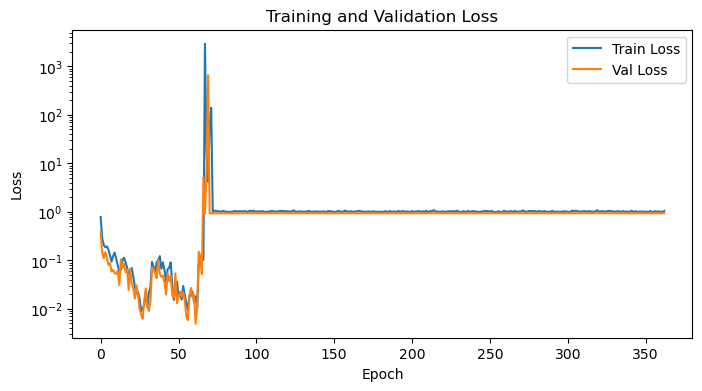

In [10]:
#Plot the training history
plt.figure(figsize=(8,4))
plt.plot(history['train'], label='Train Loss')
plt.plot(history['val'], label='Val Loss')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [11]:
#PLOT PLOTLY GRAPH FOR aCTUAL VALUES F1 to F12
import plotly.express as px
import plotly.graph_objects as go
fig = go.Figure()
for k in range(1,13):
    sub = df[df['k']==k].sort_values('Eta')
    #ri,m = k_map[int(k)]
    fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['Fval'], mode='lines', name=f'F true k={int(k)} Ri={ri} M={m}'))
    #fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['p_Fval'], mode='lines+markers', name=f'F pred k={int(k)} Ri={ri} M={m}'))
    #fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['Gval'], mode='lines+markers', name=f'G true k={int(k)} Ri={ri} M={m}'))
    #fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['p_Gval'], mode='lines+markers', name=f'G pred k={int(k)} Ri={ri} M={m}'))
fig.update_layout(title='F and G values vs Eta for different k, Ri, M', xaxis_title='Eta', yaxis_title='Values')
fig.write_html(os.path.join(OUT_DIR, "F_values_plotly.html"))
fig.show()

In [12]:
#PLOT PLOTLY GRAPH FOR aCTUAL VALUES F1 to F12
import plotly.express as px
import plotly.graph_objects as go
fig = go.Figure()
for k in range(1,13):
    sub = df[df['k']==k].sort_values('Eta')
    #ri,m = k_map[int(k)]
    #fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['Fval'], mode='lines+markers', name=f'F true k={int(k)} Ri={ri} M={m}'))
    fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['p_Fval'], mode='lines', name=f'F pred k={int(k)} Ri={ri} M={m}'))
    #fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['Gval'], mode='lines+markers', name=f'G true k={int(k)} Ri={ri} M={m}'))
    #fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['p_Gval'], mode='lines+markers', name=f'G pred k={int(k)} Ri={ri} M={m}'))
fig.update_layout(title='F and G values vs Eta for different k, Ri, M', xaxis_title='Eta', yaxis_title='Values')
fig.write_html(os.path.join(OUT_DIR, "F_Pred_values_plotly.html"))
fig.show()

In [13]:
#PLOT PLOTLY GRAPH FOR aCTUAL VALUES F1 to F12
import plotly.express as px
import plotly.graph_objects as go
fig = go.Figure()
for k in range(1,13):
    sub = df[df['k']==k].sort_values('Eta')
    #ri,m = k_map[int(k)]
    #fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['Fval'], mode='lines+markers', name=f'F true k={int(k)} Ri={ri} M={m}'))
    #fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['p_Fval'], mode='lines+markers', name=f'F pred k={int(k)} Ri={ri} M={m}'))
    fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['Gval'], mode='lines', name=f'G true k={int(k)} Ri={ri} M={m}'))
    #fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['p_Gval'], mode='lines+markers', name=f'G pred k={int(k)} Ri={ri} M={m}'))
fig.update_layout(title='F and G values vs Eta for different k, Ri, M', xaxis_title='Eta', yaxis_title='Values')
fig.write_html(os.path.join(OUT_DIR, "G_values_plotly.html"))
fig.show()

In [14]:
#PLOT PLOTLY GRAPH FOR aCTUAL VALUES F1 to F12
import plotly.express as px
import plotly.graph_objects as go
fig = go.Figure()
for k in range(1,13):
    sub = df[df['k']==k].sort_values('Eta')
    #ri,m = k_map[int(k)]
    #fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['Fval'], mode='lines+markers', name=f'F true k={int(k)} Ri={ri} M={m}'))
    #fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['p_Fval'], mode='lines+markers', name=f'F pred k={int(k)} Ri={ri} M={m}'))
    #fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['Gval'], mode='lines+markers', name=f'G true k={int(k)} Ri={ri} M={m}'))
    fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['p_Gval'], mode='lines', name=f'G pred k={int(k)} Ri={ri} M={m}'))
fig.update_layout(title='F and G values vs Eta for different k, Ri, M', xaxis_title='Eta', yaxis_title='Values')
fig.write_html(os.path.join(OUT_DIR, "G_Pred_values_plotly.html"))
fig.show()

In [15]:
#PLOT PLOTLY GRAPH FOR aCTUAL VALUES F1 to F12
import plotly.express as px
import plotly.graph_objects as go
fig = go.Figure()
for k in range(1,13):
    sub = df[df['k']==k].sort_values('Eta')
    #ri,m = k_map[int(k)]
    fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['Fval'], mode='markers', name=f'F true k={int(k)} Ri={ri} M={m}'))
    fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['p_Fval'], mode='lines', name=f'F pred k={int(k)} Ri={ri} M={m}'))
    #fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['Gval'], mode='lines+markers', name=f'G true k={int(k)} Ri={ri} M={m}'))
    #fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['p_Gval'], mode='lines+markers', name=f'G pred k={int(k)} Ri={ri} M={m}'))
fig.update_layout(title='F and G values vs Eta for different k, Ri, M', xaxis_title='Eta', yaxis_title='Values')
fig.write_html(os.path.join(OUT_DIR, "F_F-Pred_values_plotly.html"))
fig.show()

In [16]:
#PLOT PLOTLY GRAPH FOR aCTUAL VALUES F1 to F12
import plotly.express as px
import plotly.graph_objects as go
fig = go.Figure()
for k in range(1,13):
    sub = df[df['k']==k].sort_values('Eta')
    #ri,m = k_map[int(k)]
    #fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['Fval'], mode='lines+markers', name=f'F true k={int(k)} Ri={ri} M={m}'))
    #fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['p_Fval'], mode='lines+markers', name=f'F pred k={int(k)} Ri={ri} M={m}'))
    fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['Gval'], mode='lines', name=f'G true k={int(k)} Ri={ri} M={m}'))
    fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['p_Gval'], mode='markers', name=f'G pred k={int(k)} Ri={ri} M={m}'))
fig.update_layout(title='F and G values vs Eta for different k, Ri, M', xaxis_title='Eta', yaxis_title='Values')
fig.write_html(os.path.join(OUT_DIR, "G_G-Pred_values_plotly.html"))
fig.show()

In [17]:
#PLOT PLOTLY GRAPH FOR aCTUAL VALUES F1 to F12
import plotly.express as px
import plotly.graph_objects as go
fig = go.Figure()
for k in range(1,13):
    sub = df[df['k']==k].sort_values('Eta')
    #ri,m = k_map[int(k)]
    fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['Fval'], mode='lines+markers', name=f'F true k={int(k)} Ri={ri} M={m}'))
    fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['p_Fval'], mode='lines+markers', name=f'F pred k={int(k)} Ri={ri} M={m}'))
    fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['Gval'], mode='lines', name=f'G true k={int(k)} Ri={ri} M={m}'))
    fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['p_Gval'], mode='markers', name=f'G pred k={int(k)} Ri={ri} M={m}'))
fig.update_layout(title='F and G values vs Eta for different k, Ri, M', xaxis_title='Eta', yaxis_title='Values')
fig.write_html(os.path.join(OUT_DIR, "G_G-Pred_values_plotly.html"))
fig.show()